In [1]:
# Library imports
import polars as pl
import os
import dill as pickle
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load position info
video_df = pl.read_csv(r"E:\efizz\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20\processed_data\full_video_dataframe.csv")
homie_path = r"E:\efizz\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20\processed_data\homings\homings_obj.pkl"
with open(homie_path, "rb") as dill_file:
    homings = pickle.load(dill_file)
frame_by_cluster_matrix = np.load(r"E:\efizz\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20\processed_data\frame_by_synthetic_cluster_matrix.npy")

In [3]:
print(frame_by_cluster_matrix)
print(frame_by_cluster_matrix.shape)
print(video_df.shape)

[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 ...
 [30. 20.  0. ... 10.  0.  0.]
 [30. 20.  0. ... 10.  0.  0.]
 [10. 20.  0. ...  0.  0.  0.]]
(731210, 148)
(731210, 177)


In [4]:
# Because of memory constraints, let's only keep the columns we need for this module
COLUMNS_TO_KEEP = [
    "frames",
    "mouse_x_position",
    "mouse_y_position",
    "OutofshelterIdx",
    "EscapePeriod",
    "shelter",
    "barrier_present",
    "barrier_flipped",
]

# Select time 

In [5]:
video_df = video_df.select(COLUMNS_TO_KEEP)  # Prevents memory issues and computer crashes
# video_df = video_df.filter((video_df["barrier_present"] == True) & (video_df["barrier_flipped"] == False))
print(video_df)

shape: (731210, 8)
┌────────┬────────────┬────────────┬────────────┬────────────┬─────────┬────────────┬──────────────┐
│ frames ┆ mouse_x_po ┆ mouse_y_po ┆ Outofshelt ┆ EscapePeri ┆ shelter ┆ barrier_pr ┆ barrier_flip │
│ ---    ┆ sition     ┆ sition     ┆ erIdx      ┆ od         ┆ ---     ┆ esent      ┆ ped          │
│ i64    ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ bool    ┆ ---        ┆ ---          │
│        ┆ f64        ┆ f64        ┆ bool       ┆ bool       ┆         ┆ bool       ┆ bool         │
╞════════╪════════════╪════════════╪════════════╪════════════╪═════════╪════════════╪══════════════╡
│ 1      ┆ 282.676091 ┆ 245.210752 ┆ true       ┆ false      ┆ true    ┆ false      ┆ false        │
│ 2      ┆ 282.707823 ┆ 245.301877 ┆ true       ┆ false      ┆ true    ┆ false      ┆ false        │
│ 3      ┆ 282.735861 ┆ 245.385096 ┆ true       ┆ false      ┆ true    ┆ false      ┆ false        │
│ 4      ┆ 282.758866 ┆ 245.457232 ┆ true       ┆ false      ┆ true    ┆

In [6]:
homings

Homings(onset_frames=array([  4108,   5654,   8076,  12526,  22031,  32195,  91387, 178835,
       186168, 199327, 215381, 226984, 227477, 233443, 250382, 252986,
       257096, 264627, 273068, 274141, 276598, 283644, 292209, 298491,
       305840, 318433, 338493, 353811, 355863, 402838, 405147, 424174,
       428541, 431736, 437104, 441819, 458904, 462068, 462614, 471272,
       472361, 479541, 505543, 513344, 514803, 527026, 533844, 543813,
       545793, 547275, 579539, 581019, 606157, 614156, 621649, 622549,
       626447, 627397, 629064, 630015, 634170, 634915, 637122, 639039,
       640877, 649221, 650732, 663450, 674746, 675652, 678869, 681067,
       683956, 684933, 686403, 690210, 692324, 696341, 697489, 705495,
       713193, 715409, 726203], dtype=int64), offset_frames=array([  4191,   5792,   8194,  12608,  22095,  32308,  91467, 178993,
       186329, 199458, 215466, 227101, 227583, 233526, 250493, 253103,
       257211, 264733, 273133, 274216, 276718, 283718, 292315, 2986

In [7]:
onset_frames = homings.onset_frames

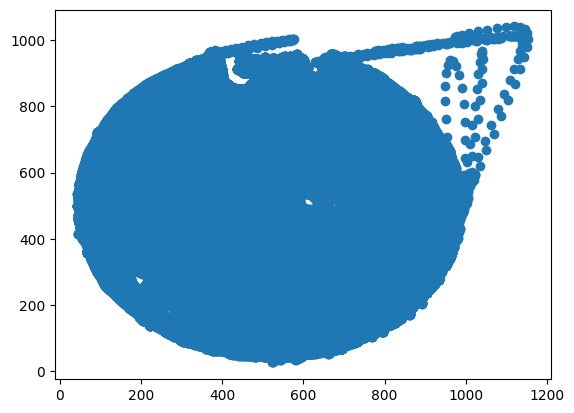

In [8]:
plt.scatter(video_df["mouse_x_position"], video_df["mouse_y_position"])

## A function to check the attributes required from the homing object exsists and to put them into a neat dictionary

In [9]:
def access_homing_attributes(homings_obj: object) -> dict:
    """Return a dictionary of verified homing attributes"""
    try:
        onset_frames = homings_obj.onset_frames
        offset_frames = homings_obj.offset_frames
    except AttributeError:
        raise AttributeError("The homings object does not have the required attributes - Something upstream is wrong with the homings object")
    assert len(onset_frames) == len(offset_frames), "The onset and offset frames are not the same length - Something is wrong with the homings object"
    return {"onset_frames": onset_frames, "offset_frames": offset_frames}

In [10]:
dic = access_homing_attributes(homings)
print(dic)
print(len(dic["onset_frames"]))

{'onset_frames': array([  4108,   5654,   8076,  12526,  22031,  32195,  91387, 178835,
       186168, 199327, 215381, 226984, 227477, 233443, 250382, 252986,
       257096, 264627, 273068, 274141, 276598, 283644, 292209, 298491,
       305840, 318433, 338493, 353811, 355863, 402838, 405147, 424174,
       428541, 431736, 437104, 441819, 458904, 462068, 462614, 471272,
       472361, 479541, 505543, 513344, 514803, 527026, 533844, 543813,
       545793, 547275, 579539, 581019, 606157, 614156, 621649, 622549,
       626447, 627397, 629064, 630015, 634170, 634915, 637122, 639039,
       640877, 649221, 650732, 663450, 674746, 675652, 678869, 681067,
       683956, 684933, 686403, 690210, 692324, 696341, 697489, 705495,
       713193, 715409, 726203], dtype=int64), 'offset_frames': array([  4191,   5792,   8194,  12608,  22095,  32308,  91467, 178993,
       186329, 199458, 215466, 227101, 227583, 233526, 250493, 253103,
       257211, 264733, 273133, 274216, 276718, 283718, 292315, 29862

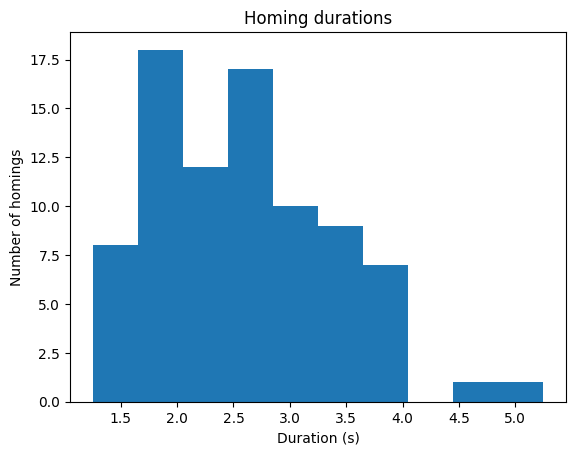

In [11]:
def plot_homing_durations(homings_dic) -> None:
    """Plot the durations of homings"""
    onset_frames = homings_dic["onset_frames"]
    offset_frames = homings_dic["offset_frames"]
    durations = (offset_frames - onset_frames) / 40 # 40 fps
    plt.hist(durations)
    plt.xlabel("Duration (s)")
    plt.ylabel("Number of homings")
    plt.title("Homing durations")
    plt.show()
plot_homing_durations(dic)

In [12]:
def check_frames_increment_by_one(arr):
    """A test to check that frames increment by 1 and as such is continuous ensuring no frames are skipped"""
    # Check each element to see if it increments by 1
    for i in range(len(arr) - 1):
        if arr[i + 1] - arr[i] != 1:
            return False
    return True

### Create some distance  bins 

[  0.         114.28571429 228.57142857 342.85714286 457.14285714
 571.42857143 685.71428571 800.        ]


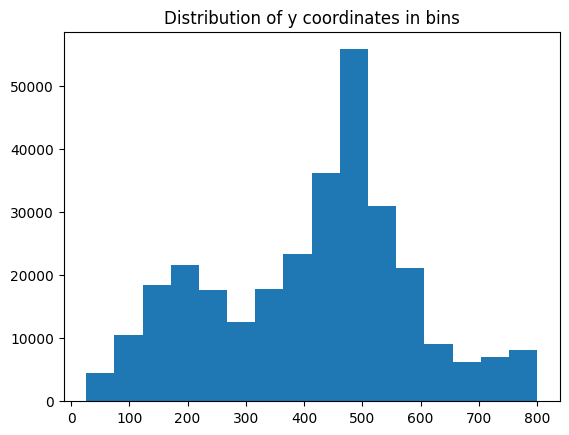

In [13]:
ycoords = video_df["mouse_y_position"]
# plt.hist(ycoords, bins=16)
# now remove y coordinats greater than 800
ycoords = ycoords.filter(ycoords < 800)
plt.hist(ycoords, bins=16)
plt.title("Distribution of y coordinates in bins")
# 8 bins would be 10cm each, so 16 bins would be 5cm each
bins = np.linspace(0, 800, 8) # Remove near shelter as there are a lot of frames there
print(bins)
# NOTE there seems to be more frames around the subgoal probably due to the turn, so we should
# probably sample the frames more uniformly across bins depending on how we want to analyse the data

In [14]:
def extract_homing_info(dic, video_df):
    """Extract homing info from video_df"""
    onset_frames = dic["onset_frames"]
    offset_frames = dic["offset_frames"]
    homing_info = []
    for onset, offset in zip(onset_frames, offset_frames):
        homing = video_df[onset:offset]
        homing_bin_idx = np.digitize(homing["mouse_y_position"], bins)
        new_column = pl.Series("bin_idx", homing_bin_idx)
        homing = homing.with_column(new_column)
        # select few columns
        homing = homing.select(["frames", "mouse_x_position", "mouse_y_position", "bin_idx"])
        homing_info.append(homing)
        
    # Check the frame column of each homing information increments uniformly by 1 such that no frames are missed
    for homing in homing_info:
        assert check_frames_increment_by_one(homing["frames"].to_numpy()), "Frames are missing in the homing information"
    
    return homing_info
info = extract_homing_info(dic, video_df)
print(info[3])

shape: (82, 4)
┌────────┬──────────────────┬──────────────────┬─────────┐
│ frames ┆ mouse_x_position ┆ mouse_y_position ┆ bin_idx │
│ ---    ┆ ---              ┆ ---              ┆ ---     │
│ i64    ┆ f64              ┆ f64              ┆ i64     │
╞════════╪══════════════════╪══════════════════╪═════════╡
│ 12527  ┆ 866.017856       ┆ 227.719817       ┆ 2       │
│ 12528  ┆ 865.81501        ┆ 228.097034       ┆ 2       │
│ 12529  ┆ 865.581416       ┆ 228.560205       ┆ 2       │
│ 12530  ┆ 865.333292       ┆ 229.14716        ┆ 3       │
│ ...    ┆ ...              ┆ ...              ┆ ...     │
│ 12605  ┆ 677.619488       ┆ 652.640743       ┆ 6       │
│ 12606  ┆ 678.185462       ┆ 652.995295       ┆ 6       │
│ 12607  ┆ 678.787875       ┆ 652.996363       ┆ 6       │
│ 12608  ┆ 679.373354       ┆ 652.72772        ┆ 6       │
└────────┴──────────────────┴──────────────────┴─────────┘


C:\Users\laurence\AppData\Local\Temp\ipykernel_29052\3346538231.py:10: DeprecationWarning: `DataFrame.with_column` has been renamed; this redirect is temporary, please use `.with_columns` instead
  homing = homing.with_column(new_column)


17


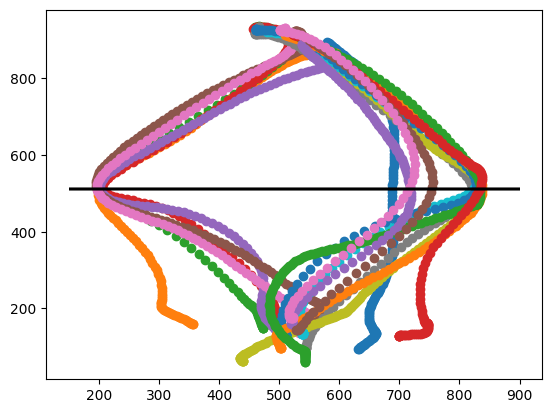

In [15]:
def select_similar_homings(info):
    """
    
    -- Similar time periods
    -- Similar mouse positions
    -- Similar targets

    Raises:
        NotImplementedError: _description_
    """
    # HARDCORE MODE - we like it rough and tough
    xcoordinate_min = 300
    xcoordinate_max = 700
    ycoordinate_min = 200
    ycoordinate_end_min = 750
    x_middle_chunk_min = 400
    x_middle_chunk_max = 600
    extracted_info = []
    for idx, homing in enumerate(info):
        
        # check if mouse x position is within the range - STARTS FARTS ONLY 
        start_x = homing["mouse_x_position"][0]
        start_y = homing["mouse_y_position"][0]
        
        # Starts in a similar space
        if start_x > xcoordinate_min and start_x < xcoordinate_max and start_y < ycoordinate_min:
            
            #Ends in a similar space
            if homing["mouse_y_position"][-1] > ycoordinate_end_min:
                
                # middle of frames is in a similar space
                middle_x = homing["mouse_x_position"][int(len(homing) / 2)]
                if middle_x < x_middle_chunk_min or middle_x > x_middle_chunk_max:
                    plt.scatter(homing["mouse_x_position"], homing["mouse_y_position"])
                    plt.hlines(y=512, xmin=150, xmax=900, color="k")
                    extracted_info.append(homing)
                    
    return extracted_info

extracted_info =  select_similar_homings(info)
print(len(extracted_info))

### Create time segmented chunks of the homings

In [16]:
# Ultimately we want a frame by cluster matrix which is filtered by a chunk of time and then added up
# I.e if we have 10 frames into a chunk, and all are columns are neurons, we then add up all the columns and this is our chunk of that homing
# info[0]
# target_y = 512
# central_frames = info[0].filter((pl.col("mouse_y_position") > 510) & (pl.col("mouse_y_position") < 514)) # As defined by the closest y coordinate to 512
# assert len(central_frame) > 0, "No frames were captured whilst the mouse was in the centre of the arena"
# # Calculate the absolute difference from the target y-coordinate
# difference_in_frames = central_frames.with_columns(
#     (pl.col("mouse_y_position") - target_y).abs().alias("distance_from_target")
# )
# # Sort by the absolute difference to find the closest frame
# closest_frame = difference_in_frames.sort("distance_from_target").limit(1)
# print(closest_frame)
# print(central_frame)

### Create distance bins 

In [17]:
for bin_idx, bin in enumerate(bins):
    for trial in extracted_info:
        # Filter the trial by the bin
        homing_chunk = trial.filter(trial["bin_idx"] == bin_idx)
        print(homing_chunk)
    

shape: (0, 4)
┌────────┬──────────────────┬──────────────────┬─────────┐
│ frames ┆ mouse_x_position ┆ mouse_y_position ┆ bin_idx │
│ ---    ┆ ---              ┆ ---              ┆ ---     │
│ i64    ┆ f64              ┆ f64              ┆ i64     │
╞════════╪══════════════════╪══════════════════╪═════════╡
└────────┴──────────────────┴──────────────────┴─────────┘
shape: (0, 4)
┌────────┬──────────────────┬──────────────────┬─────────┐
│ frames ┆ mouse_x_position ┆ mouse_y_position ┆ bin_idx │
│ ---    ┆ ---              ┆ ---              ┆ ---     │
│ i64    ┆ f64              ┆ f64              ┆ i64     │
╞════════╪══════════════════╪══════════════════╪═════════╡
└────────┴──────────────────┴──────────────────┴─────────┘
shape: (0, 4)
┌────────┬──────────────────┬──────────────────┬─────────┐
│ frames ┆ mouse_x_position ┆ mouse_y_position ┆ bin_idx │
│ ---    ┆ ---              ┆ ---              ┆ ---     │
│ i64    ┆ f64              ┆ f64              ┆ i64     │
╞════════╪════